# Mini Project : Breast Tumor Classifier

<hr style="height: 5px; background-color: pink ; border: none;">

### Introduction
This notebook assymbles all the meteial from week1 to week3 by building a machine learning model following the whole machine learning pipelibe : EDA -Data Preprocessing - Train/test split-Modeling-Evaluation.
In this mini project, we apply the full pipeline to build a **binary classification model** that distinguishes between **malignant and benign breast tumors** using the Breast Cancer dataset from scikit-learn.

### Import all the python libaries for a smoother run

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

<hr style="height: 5px; background-color: pink ; border: none;">

# Phase 1 : Exploratory Data Analysis (EDA)

## 1.1 Dataset Description

**Source:** [Breast Cancer Wisconsin (Diagnostic) Data Set](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset), Imported from  scikit-learn via `load_breast_cancer()`.

### Dataset Features
**The 10 base features**
- `radius` — mean distance from center to points on the perimeter
- `texture` — standard deviation of gray-scale values
- `perimeter` — size of the core tumor boundary
- `area` — size of the nucleus
- `smoothness` — local variation in radius lengths
- `compactness` — perimeter^2 / area - 1.0
- `concavity` — severity of concave portions of the contour
- `concave points` — number of concave portions of the contour
- `symmetry` — symmetry of the nucleus shape
- `fractal dimension` — "coastline approximation" - 1

> The original data comes from digitized images of breast cell samples. Instead of using the images directly, researchers extracted numerical measurements that describe the characteristics of the cell nuclei visible in these images.

From each image, 10 main features were measured, such as radius, texture, perimeter, and area. To capture different statistical aspects of each measurement, three values were calculated for every feature:
- **Mean:** the average value of the measurement.
- **Standard error:** the variation or uncertainty of the measurement.
- **Worst:** the average of the three largest values observed.

Therefore, each of the 10 features is represented by 3 statistical measurements, resulting in:
**10 features × 3 statistics = 30 numerical features**

These numerical features provide a way to represent the important characteristics of the original images in a format that machine learning models can process.

**Target (`target`):** binary label — `0 = malignant`, `1 = benign`. 

**Shape:** 569 samples x 30 features, no missing values (verified below).
>  All of the dataset information and descriptions were obtained using the `DESCR` attribute provided by scikit-learn.

In [29]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
dataset.keys()
print(dataset.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### Dataset Documentation

The `DESCR` attribute provides a comprehensive description of the dataset, including its source, feature definitions, summary statistics, class distribution, and data quality. According to the report, the dataset contains **569 samples**, **30 numerical features**, and **no missing values**, indicating that it is already well-prepared for machine learning tasks.

Although the dataset is already clean, we still verified its quality by checking for missing values and duplicate rows before proceeding with preprocessing and model training.


In [30]:
X = dataset.data
y = dataset.target
print(X.shape)


(569, 30)


In [31]:
import pandas as pd

df = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names
)

df["target"] = dataset.target
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [32]:
df.head(15)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,0


In [33]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 1.2 Checking Data Quality: Missing Values & Duplicates

Since this dataset is provided by the **scikit-learn library**, it is already cleaned and structured. According to the dataset description, there are no missing values.

But we can verify this using the following functions:

- `isnull().sum()` : checks the number of missing values in each column.
- `duplicated().sum()` : checks the number of duplicate rows in the dataset.

The total number of missing values and duplicate rows can be calculated as follows:

In [34]:
missing_total = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print("Total missing values in the dataset:" , missing_total)
print("Duplicate rows:" , duplicate_rows)


Total missing values in the dataset: 0
Duplicate rows: 0


## 1.3 Checking for Class Balance

> Before training a classification model, it is important to see the distribution of the target classes. Class imbalance occurs when one class has  more samples than another, which can affect the model's ability to learn patterns from the minority class and may lead to misleading evaluation results in accurecy.



Counts:
 target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64

Percentages:
 target
Benign (1)       62.7
Malignant (0)    37.3
Name: proportion, dtype: float64


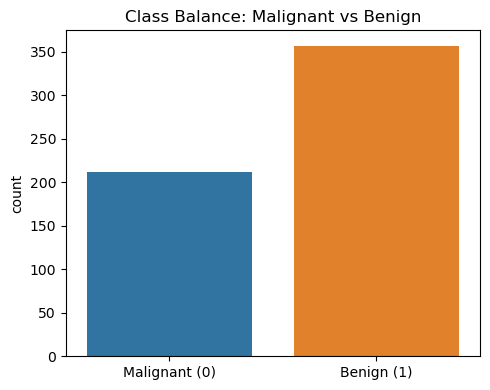

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df['target'].value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'})
class_pct = df['target'].value_counts(normalize=True).rename({0: 'Malignant (0)', 1: 'Benign (1)'}).round(3) * 100

print("Counts:\n", class_counts)
print("\nPercentages:\n", class_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='target', hue='target', legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Malignant (0)', 'Benign (1)'])
ax.set_xlabel('')
ax.set_title('Class Balance: Malignant vs Benign')
plt.tight_layout()
plt.show()

### We notice that :
The classes are **not perfectly balanced** ( almost 60% benign vs 40% malignant ), but the imbalance is mild and nowhere near the severe skew  that would force us to use techniques to change that. 
This tells us that we cannot rely on **accuracy alone** when evaluating this model in the following sections. Instead, we will use additional evaluation metrics such as **precision, recall, and F1-score** to better understand the model's performance on each class.

## 1.4 Correlations Between Features

> Using the correlation heatmap to show the relationship between numerical features. Each cell represents the **Pearson correlation coefficient**, which ranges from:
- **+1:** Strong positive relationship (both features increase together)
- **-1:** Strong negative relationship (one feature increases while the other decreases)
- **0:** No linear relationship



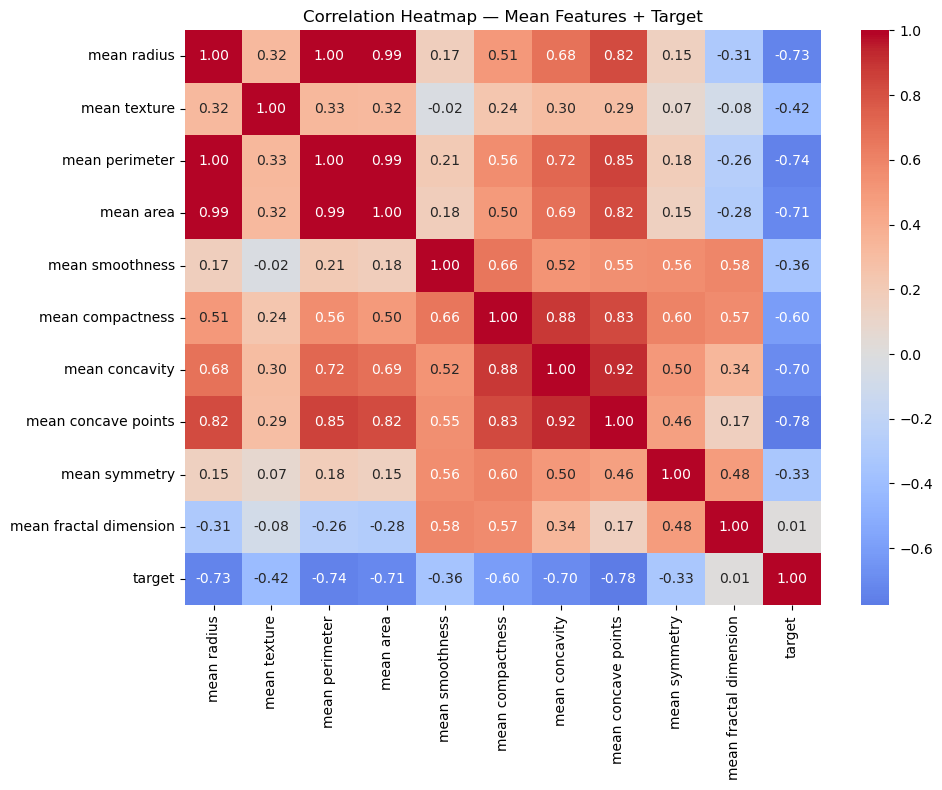

In [36]:
mean_cols = [c for c in df.columns if c.startswith('mean')]
corr = df[mean_cols + ['target']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Mean Features + Target')
plt.tight_layout()
plt.show()


### We notice that : 

- Features such as **mean radius, mean perimeter, and mean area** have a very strong correlation with each other. They all describe different measurements of tumor size.
- Some features, such as **mean concavity, mean concave points, and mean compactness**, are also strongly related to each other.

> This indicates the presence of **multicollinearity**, meaning that some features contain similar information.

- Several features, including **mean radius, mean perimeter, mean area, mean concavity, and mean concave points**, have a strong relationship with the target variable. This suggests that these features may be useful for predicting whether a tumor is malignant or benign.



## 1.5 Studying Feature Distributions Using Histograms



Each histogram represents one of the 10 **mean features** and shows how the feature values are distributed between the two tumor classes:

- **Red:** Malignant tumors
- **Blue:** Benign tumors

The x-axis represents the range of feature values, while the y-axis represents the number of samples in each value range. The smooth curve (KDE) shows the overall distribution pattern of each class.


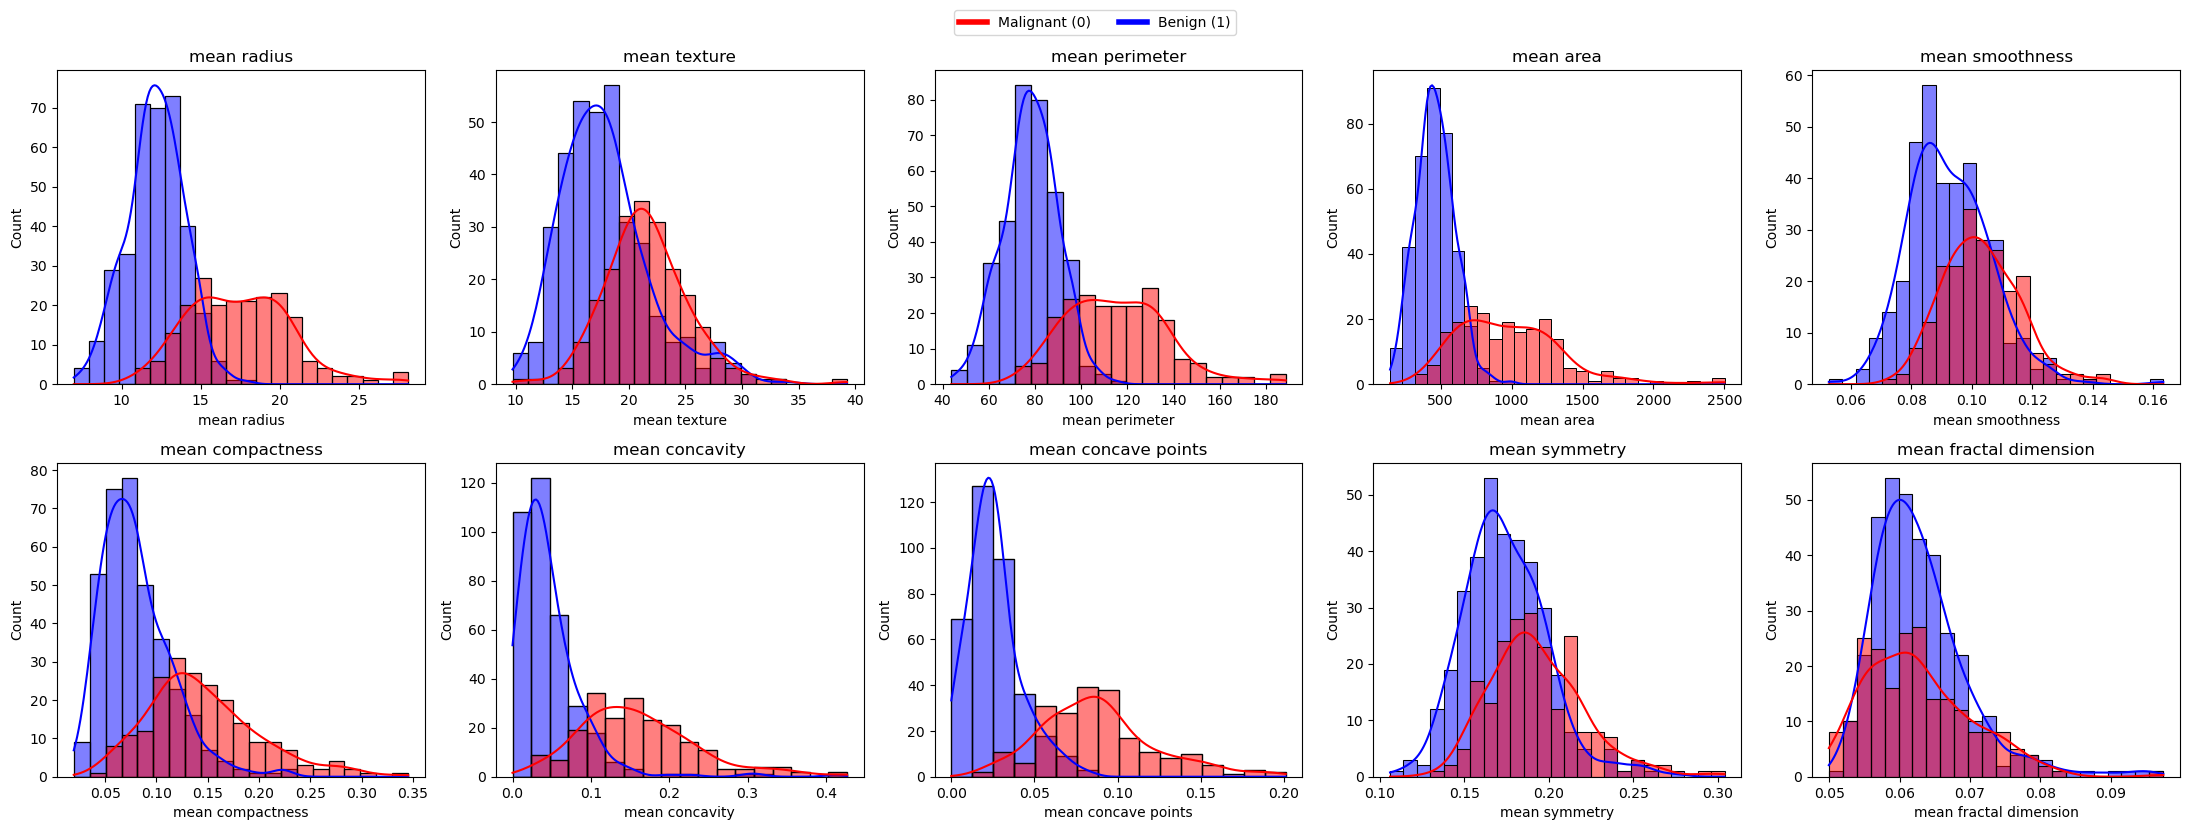

In [49]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col in zip(axes, mean_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax,
                 palette=['red', 'blue'], legend=False)
    ax.set_title(col)
handles = [plt.Line2D([0], [0], color=c, lw=4) for c in ['red', 'blue']]
fig.legend(handles, ['Malignant (0)', 'Benign (1)'], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.show()


### We notice that :

 #### 1. Features That Clearly Separate the Two Classes
 >  For some features, such as **mean radius, mean area, mean perimeter, mean concavity, and mean concave points**, the values are generally **higher for benign tumors** than for malignant  tumors. Since the two classes have different value ranges with only a small overlap, these features can help the model distinguish between malignant and benign tumors.

#### 2. Features with Similar Values in Both Classes
> For other features, such as **mean smoothness, mean symmetry, and mean fractal dimension**, the values are very similar for both classes. Because there is a large overlap between the two histograms, these features alone are less useful for separating the two classes.

#### 3. Distribution Shape  
  > Most features are right-skewed, meaning that most samples have lower values with a smaller number of samples having much higher values. This is expected for physical measurements such as tumor size, which cannot have negative values. This observation supports the need for **feature scaling** before training models such as Logistic Regression ( which is done later on in phase 2 ).

**Important:** The `standard error` and `worst` feature groups follow similar distribution patterns to the `mean` features. They are not displayed here to keep the visualization clear, but they can be explored using the same approach.

<hr style="height: 5px; background-color: pink ; border: none;">

# Phase 2 : Training The Model

> In this section, we will choose two models based on the observations from Day 3 and Day 4. After exploring different models, **Logistic Regression** and **Random Forest** performed the best with the Breast Cancer dataset.

Therefore, we will train these two models and evaluate their performance to understand how well they can classify between **malignant and benign tumors**. And choose which one is better than the other later on in the Evaluation Section

## 2.1 : Splitting the dataset into training and testing sets

In [38]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2.2 Training the logestic Regression Model 

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[41  2]
 [ 1 70]]


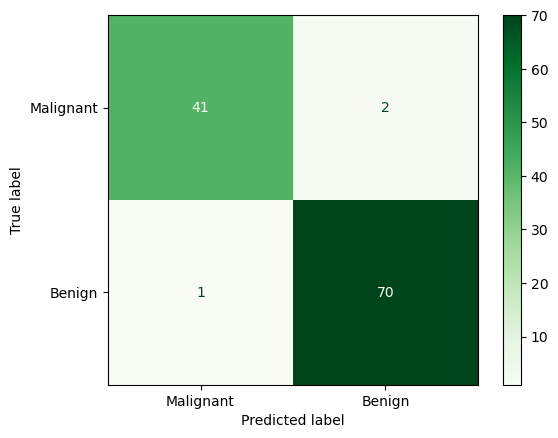

In [39]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lR_model = LogisticRegression(max_iter=4000)
lR_model.fit(X_train, y_train)
predictions = lR_model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=[ "Malignant" , "Benign"],  
    cmap="Greens"
)
plt.show()


## 2.3 Training the Random Forest Model 

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[40  3]
 [ 1 70]]


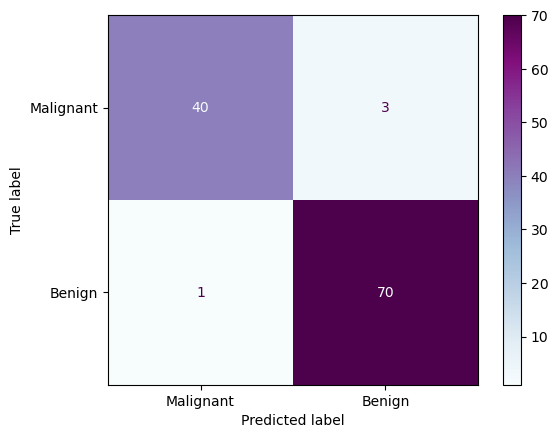

[0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
RF_model.fit(X_train, y_train)
predictions = RF_model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=[ "Malignant" , "Benign" ],
    cmap="BuPu"
)
plt.show()

print(RF_model.feature_importances_) # which features mattered most


<hr style="height: 5px; background-color: pink ; border: none;">

# Phase 3 : Evaluating The Model

## 3.1 Establishing a Baseline

Before evaluating our two models, we first need to establish a baseline performance. Which provides a  reference point that allows us to determine whether our machine learning models are actually learning useful patterns from the data.


### We will use the Dummy Classifier as a reference point
> This idea and code were took from this video: https://www.youtube.com/watch?v=6eT5cLL-2Vc

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)     # Create a classifier object
dummy_clf.fit(X_train, y_train)                                            # fit the classifier
predictions_baseline = dummy_clf.predict(X_test)                            # predict using the trained classifier

print("The accuracy of the model on the training data: %0.3f" % (dummy_clf.score(X_train, y_train)))
print(classification_report(y_test, predictions_baseline, target_names=['Malignant', 'Benign'], zero_division=0))

The accuracy of the model on the training data: 0.629
              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        43
      Benign       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



## 3.2 Choosing the Right Metric

We mentioned before that there were some mildly imbalanced in the classes and the target variables. Therefore, accuracy alone wouldn't be a right measure to make a good evaluation.

This is a **medical diagnosis** problem so the costly error is a **false negative**. Which is telling a patient with a malignant tumor that it's benign, so it goes untreated. That makes **recall on the malignant class**  the most clinically important number: of all the actually-malignant cases, what fraction did the model catch? 

We'll also track **precision**,and **F1** for a fuller picture, since optimizing recall alone would be trivial.

## 3.3 Comparing Models Against the Baseline and Other Metrecies

| Model | Accuracy | Precision (Malignant) | Recall (Malignant) | F1-score (Malignant) 
|--------|:--------:|:---------------------:|:------------------:|:--------------------:
| **Dummy Classifier** | 0.629 | 0.000 | 0.000 | 0.000 
| **Logistic Regression** | 0.97 |  0.98| 0.95 | 0.96 
| **Random Forest** | 0.96 | 0.98   |  0.93   | 0.95 


> Also acoring to the confusion Matrix: Logistic Regression misclassified 2  Malignant as Benign while Random Forest misclassified 3

### Model Comparison and Final Decision

Both **Logistic Regression** and **Random Forest** performed significantly better than the **Dummy Classifier**, which was used as our baseline. This shows that both models successfully learned meaningful patterns from the dataset instead of simply predicting the majority class.

When comparing the two trained models, **Logistic Regression** achieved slightly better overall performance. Although both models obtained the same **precision (0.98)**, Logistic Regression achieved a higher **recall (0.95 vs. 0.93)** and a higher **F1-score (0.96 vs. 0.95)**. It also achieved a slightly higher **accuracy (0.97 vs. 0.96)**.

Therefore, **Logistic Regression** is the most suitable model for this dataset. Its higher recall means it correctly identifies more malignant tumors, while maintaining excellent precision and overall performance. 